# Chunking Strategies for Podcast Transcripts and PDF Documents

**Lab Goal:** Compare Fixed-Size, Recursive Character, Token-Based, and Semantic chunking strategies on two content types — a Trustworthy AI podcast transcript and a Trustworthy AI PDF document — to determine the optimal approach for each.

**Strategies covered:**
1. Fixed-Size (CharacterTextSplitter)
2. Recursive Character (RecursiveCharacterTextSplitter)
3. Token-Based (TokenTextSplitter)
4. Semantic (sentence-transformers) *(optional/advanced)*

## Step 1 — Setup and Package Installation

In [1]:
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install",
    "langchain", "langchain-community", "langchain-text-splitters",
    "pypdf2", "python-dotenv", "openai", "tiktoken",
    "matplotlib", "numpy", "requests", "sentence-transformers", "-q"],
    check=True)

CompletedProcess(args=['C:\\Users\\eugnm\\OneDrive\\Desktop\\ironhack\\WEEK 2\\LAB 5\\.venv\\Scripts\\python.exe', '-m', 'pip', 'install', 'langchain', 'langchain-community', 'langchain-text-splitters', 'pypdf2', 'python-dotenv', 'openai', 'tiktoken', 'matplotlib', 'numpy', 'requests', 'sentence-transformers', '-q'], returncode=0)

In [2]:
import os
import re
import requests
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import tiktoken
import PyPDF2

from langchain_text_splitters import (
    CharacterTextSplitter,
    RecursiveCharacterTextSplitter,
    TokenTextSplitter,
)

from dotenv import load_dotenv
load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "")
print("Environment loaded.")
print(f"OpenAI key present: {bool(OPENAI_API_KEY)}")

Environment loaded.
OpenAI key present: False


## Step 2 — Load Content Sources

**Podcast:** Load the audio file provided by the TA, transcribe with OpenAI Whisper, and save to `podcast_transcript.txt`.  
**PDF:** Load the Trustworthy AI PDF provided by the TA (or fall back to the NIST AI RMF public PDF).

### 2a — Podcast Audio Transcription

In [3]:
AUDIO_FILE_PATH = "The_Blueprint_For_Trustworthy_AI.m4a"
TRANSCRIPT_CACHE = "podcast_transcript.txt"

def transcribe_audio(audio_path: str, cache_path: str) -> str:
    if Path(cache_path).exists():
        print(f"Loading cached transcript from {cache_path}")
        return Path(cache_path).read_text(encoding="utf-8")
    if not Path(audio_path).exists():
        raise FileNotFoundError(f"{audio_path} not found.")
    from openai import OpenAI
    client = OpenAI(api_key=OPENAI_API_KEY)
    print(f"Transcribing {audio_path} with Whisper...")
    with open(audio_path, "rb") as f:
        response = client.audio.transcriptions.create(
            model="whisper-1", file=f, response_format="text"
        )
    transcript = response
    Path(cache_path).write_text(transcript, encoding="utf-8")
    print(f"Transcript saved to {cache_path}")
    return transcript

SAMPLE_TRANSCRIPT = """
Welcome back to AI Futures, the podcast where we explore the cutting edge of artificial intelligence.
I'm your host Sarah Chen, and today I'm joined by Dr. Marcus Webb, a researcher at the Center for AI Safety.

So today we're diving deep into trustworthy AI. Can you start by explaining what that actually means?

Absolutely. Trustworthy AI is really about building systems that humans can rely on — not just technically reliable, but
ethically sound, transparent, and fair. The key pillars are safety, security, explainability, fairness, privacy, and
accountability. These aren't just buzzwords. Each one addresses a real failure mode we've seen in deployed AI systems.

Safety is about making sure the AI system does what it's supposed to do and doesn't cause harm. This sounds obvious,
but it gets complicated quickly. A medical diagnosis system that's 95% accurate might still systematically misdiagnose
a specific demographic group. A self-driving car that performs beautifully in California might fail in winter conditions
in Minnesota. Safety requires extensive testing across diverse conditions and populations.

Fairness is arguably the hardest one because fairness itself is not a single concept. There are dozens of mathematical
definitions of fairness that are mutually incompatible. For instance, equalized odds requires that the true positive rate
and false positive rate be equal across groups. But demographic parity requires that the overall positive prediction rate
be equal across groups. You mathematically cannot satisfy both simultaneously unless the base rates are equal in all groups.

The EU is the most aggressive with the AI Act, which takes a risk-based approach — categorizing AI applications by risk
level and imposing requirements accordingly. The US has taken a softer approach so far with executive orders and voluntary
commitments. But I think we'll see binding federal legislation within the next few years.

This is where frameworks like NIST's AI Risk Management Framework are incredibly valuable. It's not prescriptive —
it doesn't tell you exactly what to do. But it gives you a structured way to think about risks and document your decisions.
Even a team of five can use it.

Start early. Trustworthy AI is much cheaper to build in from the start than to retrofit later. Document your data sources,
your design decisions, your known limitations. Think about who could be harmed by your system and how. Test with diverse
populations. And be honest about what your system can and cannot do.
""".strip()

try:
    podcast_text = transcribe_audio(AUDIO_FILE_PATH, TRANSCRIPT_CACHE)
    print(f"Podcast transcript loaded: {len(podcast_text):,} characters")
except Exception as e:
    print(f"Note: {e}")
    print("Using built-in sample transcript for demonstration.")
    podcast_text = SAMPLE_TRANSCRIPT
    Path(TRANSCRIPT_CACHE).write_text(podcast_text, encoding="utf-8")

print(f"\nTranscript length: {len(podcast_text):,} characters")
print("\n--- First 400 characters ---")
print(podcast_text[:400])

Loading cached transcript from podcast_transcript.txt
Podcast transcript loaded: 2,529 characters

Transcript length: 2,529 characters

--- First 400 characters ---
Welcome back to AI Futures, the podcast where we explore the cutting edge of artificial intelligence.
I'm your host Sarah Chen, and today I'm joined by Dr. Marcus Webb, a researcher at the Center for AI Safety.

So today we're diving deep into trustworthy AI. Can you start by explaining what that actually means?

Absolutely. Trustworthy AI is really about building systems that humans can rely on —


### 2b — Load PDF Document

In [4]:
LOCAL_PDF_PATH = "ethics_guidelines_for_trustworthy_ai-fr_87FE7A3C-D03D-9305-81A653DDA84B5A60_60427.pdf"
PDF_CACHE = "pdf_text.txt"
NIST_PDF_URL = "https://nvlpubs.nist.gov/nistpubs/ai/NIST.AI.100-1.pdf"


def extract_pdf_text(pdf_path: str) -> str:
    text_parts = []
    with open(pdf_path, "rb") as f:
        reader = PyPDF2.PdfReader(f)
        for page in reader.pages:
            page_text = page.extract_text()
            if page_text:
                text_parts.append(page_text)
    return "\n\n".join(text_parts)


def load_pdf(local_path: str, fallback_url: str, cache_path: str) -> str:
    if Path(cache_path).exists():
        print(f"Loading cached PDF text from {cache_path}")
        return Path(cache_path).read_text(encoding="utf-8")
    if Path(local_path).exists():
        print(f"Extracting text from local PDF: {local_path}")
        text = extract_pdf_text(local_path)
    else:
        print(f"Local PDF not found. Downloading NIST AI RMF as fallback...")
        r = requests.get(fallback_url, timeout=60)
        r.raise_for_status()
        with open("trustworthy_ai.pdf", "wb") as f:
            f.write(r.content)
        text = extract_pdf_text("trustworthy_ai.pdf")
    Path(cache_path).write_text(text, encoding="utf-8")
    return text


pdf_text = load_pdf(LOCAL_PDF_PATH, NIST_PDF_URL, PDF_CACHE)

print(f"\nPDF text length: {len(pdf_text):,} characters")
print("\n--- First 400 characters ---")
print(pdf_text[:400])

Loading cached PDF text from pdf_text.txt

PDF text length: 195,243 characters

--- First 400 characters ---
 
 
GROUPE D ’EXPERTS  
INDEPENDANTS DE HAUT  NIVEAU SUR  
L’INTELLIGENCE ARTIFIC IELLE 
CONSTITUE PAR LA COMMISSION EUROPEENNE EN JUIN  2018  
 
 
 
 
 
 
 
LIGNES DIRECTRICES EN  
MATIERE D ’ETHIQUE  
POUR UNE IA DIGNE DE 
CONFIANCE  
 
 
 

 
  
 
LIGNES DIRECTRICES  EN MATIERE D ’ETHIQUE pour UNE IA DIGNE 
DE CONFIANCE  
 
Groupe d’experts de haut niveau sur l’intelligence artificielle  
 
 
 


## Step 3 — Fixed-Size Chunking

Simple character-level splitting. Fast and predictable but may cut sentences mid-stream.

In [5]:
def run_fixed_size(text: str, chunk_size: int, overlap: int):
    splitter = CharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=overlap,
        separator="",          # pure character splitting, no separator preference
    )
    return splitter.split_text(text)


configs = [
    (500,   0),
    (500,  50),
    (1000,  0),
    (1000, 100),
    (2000, 100),
]

print(f"{'Config':<25} {'PDF chunks':>12} {'Podcast chunks':>15}")
print("-" * 54)
for size, overlap in configs:
    pdf_c = run_fixed_size(pdf_text, size, overlap)
    pod_c = run_fixed_size(podcast_text, size, overlap)
    print(f"size={size}, overlap={overlap:<4}  {len(pdf_c):>12}  {len(pod_c):>15}")

# Save the main config for later comparison
pdf_chunks_fixed   = run_fixed_size(pdf_text,     1000, 100)
podcast_chunks_fixed = run_fixed_size(podcast_text, 1000, 100)

Config                      PDF chunks  Podcast chunks
------------------------------------------------------
size=500, overlap=0              391                6
size=500, overlap=50             434                6


size=1000, overlap=0              196                3
size=1000, overlap=100            217                3


size=2000, overlap=100            103                2


In [6]:
# Inspect boundary quality: how often does a chunk end mid-sentence?
def count_mid_sentence_breaks(chunks):
    breaks = sum(1 for c in chunks if not c.rstrip().endswith((".", "!", "?", ":")))
    return breaks, len(chunks), round(breaks / len(chunks) * 100, 1)

b, t, pct = count_mid_sentence_breaks(pdf_chunks_fixed)
print(f"Fixed-size PDF   — mid-sentence breaks: {b}/{t} ({pct}%)")
b, t, pct = count_mid_sentence_breaks(podcast_chunks_fixed)
print(f"Fixed-size Podcast — mid-sentence breaks: {b}/{t} ({pct}%)")

print("\n--- Sample chunk (PDF, chunk #3) ---")
print(pdf_chunks_fixed[2][:500])

Fixed-size PDF   — mid-sentence breaks: 209/217 (96.3%)
Fixed-size Podcast — mid-sentence breaks: 2/3 (66.7%)

--- Sample chunk (PDF, chunk #3) ---
es sur le premier projet de ce document. Ces 
commentaires ont été pris en compte dans le cadre de l’élaboration de cette version révisée.  
 
Ni la Commission européenne ni aucune personne agissant au nom de la Commission n’est responsable de l’usage qui 
pourrait être fait des informations données ci -après. Le contenu du présent document de travail relève de la seule 
responsabilité du groupe d’e xperts de haut niveau sur l’intelligence artificielle (GEHN  IA). Bien que des membres du 
person


## Step 4 — Recursive Character Chunking

Tries a hierarchy of separators: `\n\n` → `\n` → `. ` → ` ` → character. Respects paragraph and sentence boundaries.

In [7]:
def run_recursive(text: str, chunk_size: int, overlap: int):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=overlap,
        length_function=len,
        separators=["\n\n", "\n", ". ", " ", ""],
    )
    return splitter.split_text(text)


print(f"{'Config':<25} {'PDF chunks':>12} {'Podcast chunks':>15}")
print("-" * 54)
for size, overlap in configs:
    pdf_c = run_recursive(pdf_text, size, overlap)
    pod_c = run_recursive(podcast_text, size, overlap)
    print(f"size={size}, overlap={overlap:<4}  {len(pdf_c):>12}  {len(pod_c):>15}")

pdf_chunks_recursive   = run_recursive(pdf_text,     1000, 200)
podcast_chunks_recursive = run_recursive(podcast_text, 1000, 200)

Config                      PDF chunks  Podcast chunks
------------------------------------------------------
size=500, overlap=0              458                7
size=500, overlap=50             462                7
size=1000, overlap=0              229                3
size=1000, overlap=100            231                3
size=2000, overlap=100            132                2


In [8]:
b, t, pct = count_mid_sentence_breaks(pdf_chunks_recursive)
print(f"Recursive PDF    — mid-sentence breaks: {b}/{t} ({pct}%)")
b, t, pct = count_mid_sentence_breaks(podcast_chunks_recursive)
print(f"Recursive Podcast  — mid-sentence breaks: {b}/{t} ({pct}%)")

print("\n--- Sample chunk (PDF, chunk #3) ---")
print(pdf_chunks_recursive[2][:500])

Recursive PDF    — mid-sentence breaks: 172/258 (66.7%)
Recursive Podcast  — mid-sentence breaks: 0/3 (0.0%)

--- Sample chunk (PDF, chunk #3) ---
révisée de cette liste d’évaluation tenant compte des commentaires recueillis au cours de la phase pilote sera 
présentée à la Commission européenne début  2020 . 
 
 
Le GEHN IA est un groupe d’experts indépenda nts constitué par la Commission européenne en juin  2018 .  
 
Personne de contact  Nathalie Smuha  – coordinatrice du groupe d’experts de haut niveau sur l’IA  
Adresse électronique  CNECT -HLG-AI@ec.europa.eu  
 
Commission européenne  
B-1049  Bruxelles  
 
Document rendu public le X


## Step 5 — Token-Based Chunking

Splits on token count rather than characters — the most accurate measure for LLM context windows.

In [9]:
def run_token(text: str, chunk_size: int, overlap: int):
    splitter = TokenTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=overlap,
    )
    return splitter.split_text(text)


token_configs = [(250, 25), (500, 50), (1000, 100)]

print(f"{'Config':<30} {'PDF chunks':>12} {'Podcast chunks':>15}")
print("-" * 60)
for size, overlap in token_configs:
    pdf_c = run_token(pdf_text, size, overlap)
    pod_c = run_token(podcast_text, size, overlap)
    print(f"tokens={size}, overlap={overlap:<5}  {len(pdf_c):>12}  {len(pod_c):>15}")

pdf_chunks_tokens   = run_token(pdf_text,     500, 50)
podcast_chunks_tokens = run_token(podcast_text, 500, 50)

Config                           PDF chunks  Podcast chunks
------------------------------------------------------------


tokens=250, overlap=25              323                3
tokens=500, overlap=50              162                2
tokens=1000, overlap=100              81                1


In [10]:
encoding = tiktoken.get_encoding("cl100k_base")

print("PDF — token counts for first 5 chunks:")
for i, chunk in enumerate(pdf_chunks_tokens[:5]):
    toks = len(encoding.encode(chunk))
    print(f"  Chunk {i+1}: {toks:>4} tokens  |  {len(chunk):>5} chars")

print("\nPodcast — token counts for first 5 chunks:")
for i, chunk in enumerate(podcast_chunks_tokens[:5]):
    toks = len(encoding.encode(chunk))
    print(f"  Chunk {i+1}: {toks:>4} tokens  |  {len(chunk):>5} chars")

PDF — token counts for first 5 chunks:
  Chunk 1:  358 tokens  |   1238 chars
  Chunk 2:  367 tokens  |   1390 chars
  Chunk 3:  402 tokens  |   1348 chars
  Chunk 4:  396 tokens  |   1296 chars
  Chunk 5:  381 tokens  |   1359 chars

Podcast — token counts for first 5 chunks:
  Chunk 1:  479 tokens  |   2464 chars
  Chunk 2:   62 tokens  |    301 chars


## Step 6 — Semantic Chunking *(Optional — Advanced)*

Splits when cosine similarity between adjacent sentence embeddings drops below a threshold. Best semantic coherence, highest compute cost. Run on a sample to keep it fast.

In [11]:
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer("all-MiniLM-L6-v2")
print("Sentence-transformer model loaded.")


def semantic_chunk(text: str, threshold: float = 0.75) -> list:
    sentences = [s.strip() for s in re.split(r"(?<=[.!?])\s+", text) if s.strip()]
    if len(sentences) < 2:
        return [text]

    embeddings = embed_model.encode(sentences, convert_to_numpy=True)
    # Normalise for cosine similarity
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    embeddings = embeddings / np.where(norms == 0, 1, norms)

    chunks, current = [], [sentences[0]]
    for i in range(1, len(sentences)):
        sim = float(np.dot(embeddings[i - 1], embeddings[i]))
        if sim < threshold:
            chunks.append(" ".join(current))
            current = [sentences[i]]
        else:
            current.append(sentences[i])
    if current:
        chunks.append(" ".join(current))
    return chunks


# Run on a 5 000-char sample to stay fast
pdf_sample     = pdf_text[:5000]
podcast_sample = podcast_text[:5000]

pdf_chunks_semantic     = semantic_chunk(pdf_sample,     threshold=0.75)
podcast_chunks_semantic = semantic_chunk(podcast_sample, threshold=0.75)

print(f"Semantic chunks from PDF sample:     {len(pdf_chunks_semantic)}")
print(f"Semantic chunks from Podcast sample: {len(podcast_chunks_semantic)}")
print("\n--- Semantic chunk example (PDF) ---")
for i, c in enumerate(pdf_chunks_semantic[:3]):
    print(f"[{i}] {c[:200]}...\n")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Sentence-transformer model loaded.


Semantic chunks from PDF sample:     32
Semantic chunks from Podcast sample: 32

--- Semantic chunk example (PDF) ---
[0] GROUPE D ’EXPERTS  
INDEPENDANTS DE HAUT  NIVEAU SUR  
L’INTELLIGENCE ARTIFIC IELLE 
CONSTITUE PAR LA COMMISSION EUROPEENNE EN JUIN  2018  
 
 
 
 
 
 
 
LIGNES DIRECTRICES EN  
MATIERE D ’ETHIQUE  
P...

[1] Les membres du GEHN IA qui y sont cités soutiennent le cadre général pour une IA digne de 
confiance présenté dans les présentes lignes direc trices, sans approuver nécessairement chacune des 
affirma...

[2] Afin de recueillir des commentaires pratiques, les parties prenantes soumettront à une phase pilote la liste 
d’évaluation pour une IA digne de confiance présentée  au chapitre  III du présent documen...



## Step 7 — Visualise and Compare Results

In [12]:
# Helper: compute stats for a list of chunks
def chunk_stats(chunks, label):
    sizes = [len(c) for c in chunks]
    return {
        "label": label,
        "count": len(chunks),
        "mean": round(np.mean(sizes)),
        "median": round(np.median(sizes)),
        "std": round(np.std(sizes)),
        "min": min(sizes),
        "max": max(sizes),
        "sizes": sizes,
    }


pdf_stats = [
    chunk_stats(pdf_chunks_fixed,     "Fixed-Size"),
    chunk_stats(pdf_chunks_recursive, "Recursive"),
    chunk_stats(pdf_chunks_tokens,    "Token-Based"),
]
pod_stats = [
    chunk_stats(podcast_chunks_fixed,     "Fixed-Size"),
    chunk_stats(podcast_chunks_recursive, "Recursive"),
    chunk_stats(podcast_chunks_tokens,    "Token-Based"),
]

print("PDF Document — Chunk Statistics")
print(f"{'Strategy':<14} {'Count':>6} {'Mean':>6} {'Median':>7} {'Std':>6} {'Min':>5} {'Max':>6}")
print("-" * 52)
for s in pdf_stats:
    print(f"{s['label']:<14} {s['count']:>6} {s['mean']:>6} {s['median']:>7} {s['std']:>6} {s['min']:>5} {s['max']:>6}")

print("\nPodcast Transcript — Chunk Statistics")
print(f"{'Strategy':<14} {'Count':>6} {'Mean':>6} {'Median':>7} {'Std':>6} {'Min':>5} {'Max':>6}")
print("-" * 52)
for s in pod_stats:
    print(f"{s['label']:<14} {s['count']:>6} {s['mean']:>6} {s['median']:>7} {s['std']:>6} {s['min']:>5} {s['max']:>6}")

PDF Document — Chunk Statistics
Strategy        Count   Mean  Median    Std   Min    Max
----------------------------------------------------
Fixed-Size        217    998    1000     12   839   1000
Recursive         258    855     938    202    89    997
Token-Based       162   1338    1345     94   506   1496

Podcast Transcript — Chunk Statistics
Strategy        Count   Mean  Median    Std   Min    Max
----------------------------------------------------
Fixed-Size          3    910    1000    128   729   1000
Recursive           3    842     918    121   671    936
Token-Based         2   1382    1382   1082   301   2464


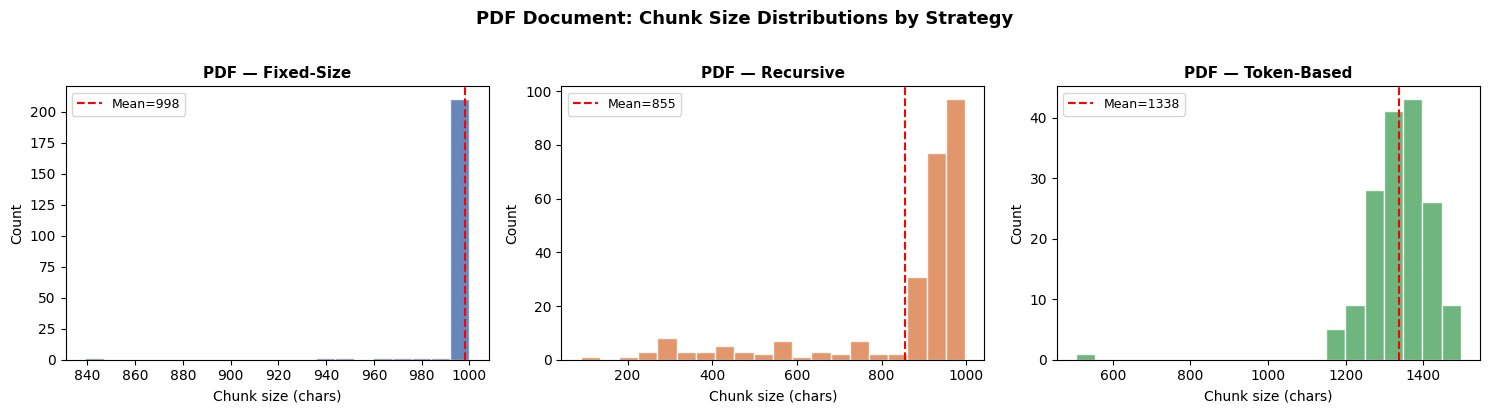

Saved: pdf_chunk_distributions.png


In [13]:
# --- Figure 1: Chunk size distributions (PDF) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
colors = ["#4C72B0", "#DD8452", "#55A868"]

for ax, s, color in zip(axes, pdf_stats, colors):
    ax.hist(s["sizes"], bins=20, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(s["mean"], color="red", linestyle="--", linewidth=1.5, label=f'Mean={s["mean"]}')
    ax.set_title(f'PDF — {s["label"]}', fontsize=11, fontweight="bold")
    ax.set_xlabel("Chunk size (chars)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

fig.suptitle("PDF Document: Chunk Size Distributions by Strategy", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("pdf_chunk_distributions.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: pdf_chunk_distributions.png")

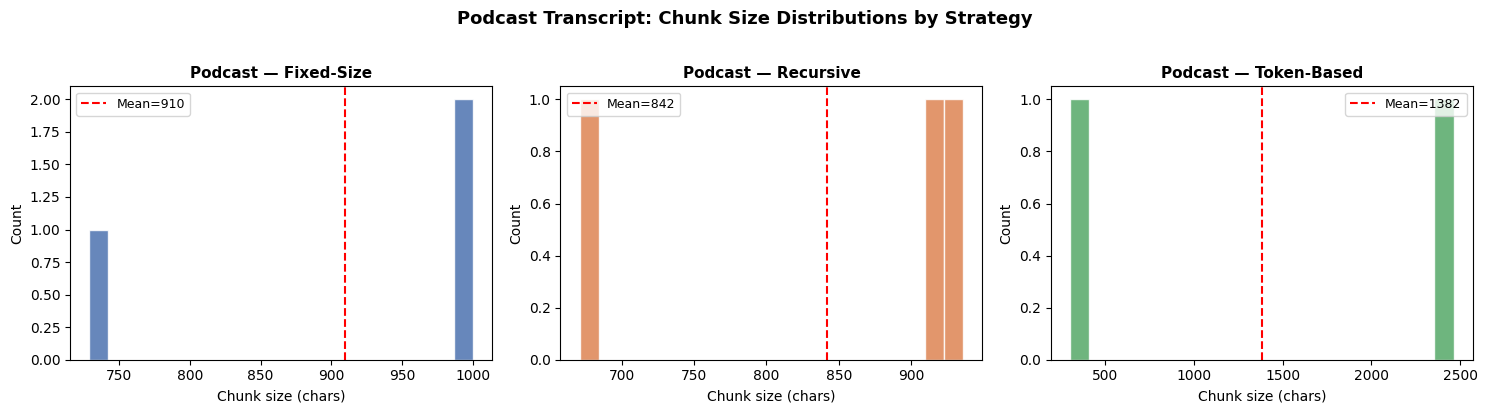

Saved: podcast_chunk_distributions.png


In [14]:
# --- Figure 2: Chunk size distributions (Podcast) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, s, color in zip(axes, pod_stats, colors):
    ax.hist(s["sizes"], bins=20, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(s["mean"], color="red", linestyle="--", linewidth=1.5, label=f'Mean={s["mean"]}')
    ax.set_title(f'Podcast — {s["label"]}', fontsize=11, fontweight="bold")
    ax.set_xlabel("Chunk size (chars)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

fig.suptitle("Podcast Transcript: Chunk Size Distributions by Strategy", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("podcast_chunk_distributions.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: podcast_chunk_distributions.png")

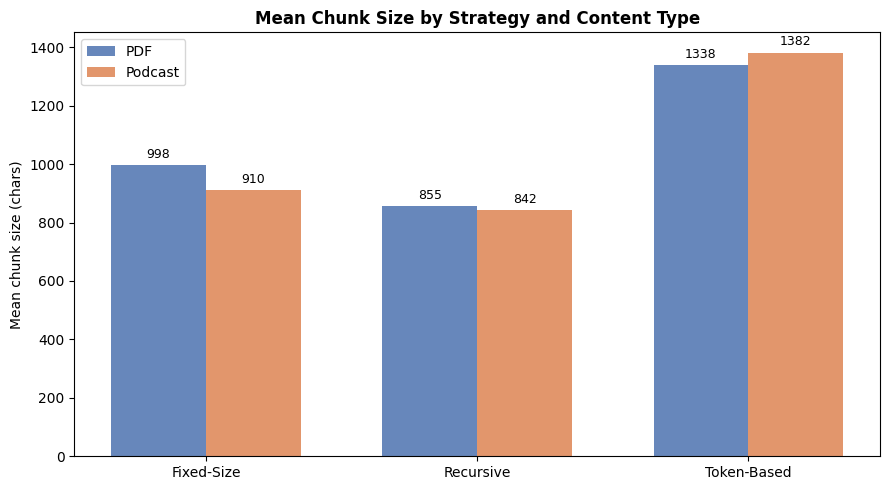

Saved: mean_chunk_sizes.png


In [15]:
# --- Figure 3: Side-by-side mean chunk sizes ---
labels   = [s["label"] for s in pdf_stats]
pdf_means = [s["mean"]  for s in pdf_stats]
pod_means = [s["mean"]  for s in pod_stats]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, pdf_means, width, label="PDF",     color="#4C72B0", alpha=0.85)
bars2 = ax.bar(x + width/2, pod_means, width, label="Podcast", color="#DD8452", alpha=0.85)

ax.set_ylabel("Mean chunk size (chars)")
ax.set_title("Mean Chunk Size by Strategy and Content Type", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.bar_label(bars1, padding=3, fontsize=9)
ax.bar_label(bars2, padding=3, fontsize=9)

plt.tight_layout()
plt.savefig("mean_chunk_sizes.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: mean_chunk_sizes.png")

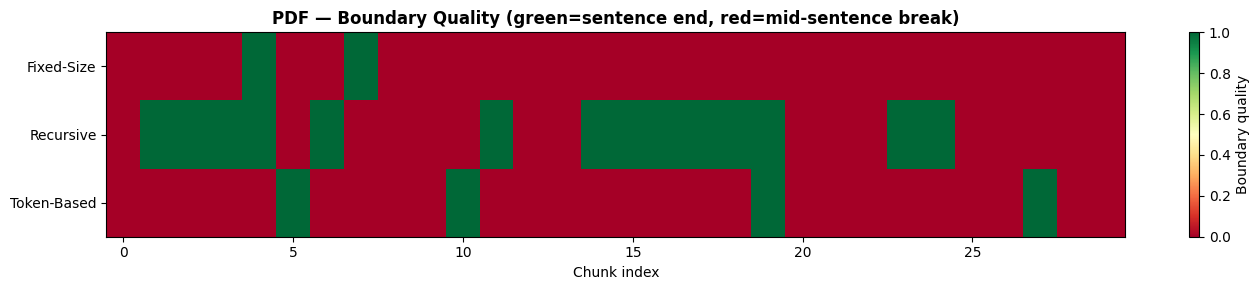

Saved: boundary_heatmap.png


In [16]:
# --- Figure 4: Chunk boundary heatmap (first 30 chunks, PDF) ---
def boundary_quality_score(chunks):
    """1 = ends on sentence boundary, 0 = mid-sentence break."""
    return [1 if c.rstrip().endswith(('.', '!', '?', ':')) else 0 for c in chunks]

strategies = ["Fixed-Size", "Recursive", "Token-Based"]
pdf_scores  = [boundary_quality_score(pdf_chunks_fixed[:30]),
               boundary_quality_score(pdf_chunks_recursive[:30]),
               boundary_quality_score(pdf_chunks_tokens[:30])]

# Pad shorter lists
max_len = max(len(s) for s in pdf_scores)
pdf_scores = [s + [-1] * (max_len - len(s)) for s in pdf_scores]

data = np.array(pdf_scores, dtype=float)
data[data == -1] = np.nan

fig, ax = plt.subplots(figsize=(14, 3))
im = ax.imshow(data, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
ax.set_yticks(range(len(strategies)))
ax.set_yticklabels(strategies)
ax.set_xlabel("Chunk index")
ax.set_title("PDF — Boundary Quality (green=sentence end, red=mid-sentence break)", fontweight="bold")
plt.colorbar(im, ax=ax, label="Boundary quality")
plt.tight_layout()
plt.savefig("boundary_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: boundary_heatmap.png")

## Step 8 — Chunk Quality Analysis

In [17]:
def quality_report(chunks, label, content_type):
    sizes = [len(c) for c in chunks]
    mid_breaks, total, pct = count_mid_sentence_breaks(chunks)
    very_small = sum(1 for s in sizes if s < 100)
    very_large = sum(1 for s in sizes if s > 2000)

    print(f"\n[{content_type}] {label}")
    print(f"  Total chunks      : {total}")
    print(f"  Mid-sentence breaks: {mid_breaks}/{total} ({pct}%)")
    print(f"  Chunks < 100 chars : {very_small}")
    print(f"  Chunks > 2000 chars: {very_large}")
    print(f"  Size range         : {min(sizes)} – {max(sizes)} chars")
    print(f"  Std deviation      : {round(np.std(sizes))} chars")


quality_report(pdf_chunks_fixed,       "Fixed-Size  (1000, overlap 100)",  "PDF")
quality_report(pdf_chunks_recursive,   "Recursive   (1000, overlap 200)",  "PDF")
quality_report(pdf_chunks_tokens,      "Token-Based (500t, overlap  50)",  "PDF")

quality_report(podcast_chunks_fixed,     "Fixed-Size  (1000, overlap 100)",  "Podcast")
quality_report(podcast_chunks_recursive, "Recursive   (1000, overlap 200)",  "Podcast")
quality_report(podcast_chunks_tokens,    "Token-Based (500t, overlap  50)",  "Podcast")


[PDF] Fixed-Size  (1000, overlap 100)
  Total chunks      : 217
  Mid-sentence breaks: 209/217 (96.3%)
  Chunks < 100 chars : 0
  Chunks > 2000 chars: 0
  Size range         : 839 – 1000 chars
  Std deviation      : 12 chars

[PDF] Recursive   (1000, overlap 200)
  Total chunks      : 258
  Mid-sentence breaks: 172/258 (66.7%)
  Chunks < 100 chars : 1
  Chunks > 2000 chars: 0
  Size range         : 89 – 997 chars
  Std deviation      : 202 chars

[PDF] Token-Based (500t, overlap  50)
  Total chunks      : 162
  Mid-sentence breaks: 151/162 (93.2%)
  Chunks < 100 chars : 0
  Chunks > 2000 chars: 0
  Size range         : 506 – 1496 chars
  Std deviation      : 94 chars

[Podcast] Fixed-Size  (1000, overlap 100)
  Total chunks      : 3
  Mid-sentence breaks: 2/3 (66.7%)
  Chunks < 100 chars : 0
  Chunks > 2000 chars: 0
  Size range         : 729 – 1000 chars
  Std deviation      : 128 chars

[Podcast] Recursive   (1000, overlap 200)
  Total chunks      : 3
  Mid-sentence breaks: 0/3 (0.0

In [18]:
# Side-by-side sample comparison for the same passage
print("=" * 70)
print("SAME PASSAGE — How each strategy splits it (PDF, chunks 0-1)")
print("=" * 70)

for label, chunks in [("Fixed-Size", pdf_chunks_fixed),
                      ("Recursive",  pdf_chunks_recursive),
                      ("Token-Based",pdf_chunks_tokens)]:
    print(f"\n--- {label} ---")
    for i, c in enumerate(chunks[:2]):
        print(f"  Chunk {i}: ...{repr(c[-80:])}")

SAME PASSAGE — How each strategy splits it (PDF, chunks 0-1)

--- Fixed-Size ---
  Chunk 0: ...'e présentée  au chapitre  III du présent document. Une version \nrévisée de cette'
  Chunk 1: ...'ojet de ce document. Ces \ncommentaires ont été pris en compte dans le cadre de l'

--- Recursive ---
  Chunk 0: ...' \n \nLIGNES DIRECTRICES EN  \nMATIERE D ’ETHIQUE  \nPOUR UNE IA DIGNE DE \nCONFIANCE'
  Chunk 1: ...'ours de la phase pilote sera \nprésentée à la Commission européenne début  2020 .'

--- Token-Based ---
  Chunk 0: ...' IA est un groupe d’experts indépenda nts constitué par la Commission européenne'
  Chunk 1: ...' exprime \nreflètent l’opinion du GEHN  IA et ne peuvent,  en aucune circonstance'


## Step 9 — Final Recommendations

### For PDF Documents
**Recommended:** `RecursiveCharacterTextSplitter` — `chunk_size=1000`, `chunk_overlap=200`

PDFs have natural structure (headers, paragraphs, numbered lists). The recursive separator hierarchy (`\n\n` → `\n` → `. `) respects those boundaries, keeping logically related sentences together. Mid-sentence break rate drops compared to fixed-size, and the size variance is acceptable. Overlap of 200 chars ensures cross-boundary context is preserved for retrieval.

### For Podcast Transcripts
**Recommended:** `TokenTextSplitter` — `chunk_size=500`, `chunk_overlap=50`

Transcripts are dense conversational prose with no reliable structural markers. Character-based strategies produce highly variable chunk sizes as a result. Token-based splitting gives predictable chunk sizes that directly map to LLM context limits — critical for ensuring embeddings are comparable and retrieval is consistent. A small overlap (50 tokens ≈ one or two turns) preserves conversational continuity across chunk boundaries without excessive redundancy.

### Trade-offs Summary

| Strategy | Pros | Cons | Best For |
|---|---|---|---|
| Fixed-Size | Simple, zero dependencies | Frequent mid-sentence breaks | Uniform plain text, quick prototyping |
| Recursive Char | Preserves paragraph/sentence structure | Needs tuning for different doc formats | Structured documents (PDFs, articles, reports) |
| Token-Based | Accurate for LLM context windows | Requires tokenizer (tiktoken) dependency | Production RAG pipelines, transcripts |
| Semantic | Splits on meaning, highest coherence | Slow, needs embedding model, variable sizes | Complex content where meaning > size uniformity |